# DP_LR - Differentially Private Logistic Regression

This notebook:
- Loads preprocessed data from data_preprocessor.ipynb
- Loads baseline results from STD_LR
- Trains DP Logistic Regression with different epsilon values
- Runs 30 iterations per epsilon to capture DP stochasticity
- Reports mean ± std for all metrics
- Saves results to JSON with per-run data

In [1]:
# Import Libraries
import time
import numpy as np
import pickle
import json
import warnings
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from diffprivlib.models import LogisticRegression as DPLogisticRegression
warnings.filterwarnings("ignore")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 1. Load Preprocessed Data

In [2]:
# Load data from data_preprocessor.ipynb
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)
data_norm = 1.0

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Testing Set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Data norm (max L2): {data_norm:.4f}")

Training Set: 56553 samples
Testing Set: 14139 samples
Number of features: 21
Data norm (max L2): 1.0000


## 2. Load Baseline Results

In [3]:
# Load baseline results from STD_LR
try:
    with open('./output/std_lr_report.json', 'r') as f:
        baseline = json.load(f)

    baseline_accuracy = baseline['metrics']['accuracy']
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
except FileNotFoundError:
    print("Warning: std_lr_report.json not found. Run STD_LR.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded successfully!
Baseline Accuracy: 0.7455


## 3. Define Epsilon Values and Run Configuration

Lower epsilon = more privacy, more noise, potentially lower accuracy.
Higher epsilon = less privacy, less noise, potentially higher accuracy.

We run 30 iterations per epsilon to capture the variance introduced by the DP mechanism.

In [4]:
# Epsilon values to test
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]

N_RUNS = 30  # runs per epsilon to capture DP stochasticity

print(f"Epsilon values: {epsilon_values}")
print(f"Runs per epsilon: {N_RUNS}")

Epsilon values: [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
Runs per epsilon: 30


## 4. Detailed Evaluation at ε=1.0 (Multiple Runs)

In [5]:
epsilon = 1

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_roc_aucs = []
detail_cms = []

print(f"Training DP Logistic Regression {N_RUNS} times with epsilon={epsilon}...")
print("=" * 80)

detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed = run * 10 + 42

    dp_model = DPLogisticRegression(
        epsilon=epsilon,
        max_iter=1000,
        random_state=seed,
        data_norm=1.0
    )

    _t0 = time.perf_counter()
    dp_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_pred = dp_model.predict(X_test)
    y_pred_proba = dp_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    detail_extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    detail_accuracies.append(acc)
    detail_f1s.append(f1)
    detail_precisions.append(prec)
    detail_recalls.append(rec)
    detail_roc_aucs.append(roc_auc)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {acc:.4f} | F1: {f1:.4f} | "
            f"Prec: {prec:.4f} | Rec: {rec:.4f} | AUC: {roc_auc:.4f}")

print("=" * 80)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {np.mean(detail_accuracies):.4f} ± {np.std(detail_accuracies):.4f}")
print(f"  F1-Score:  {np.mean(detail_f1s):.4f} ± {np.std(detail_f1s):.4f}")
print(f"  Precision: {np.mean(detail_precisions):.4f} ± {np.std(detail_precisions):.4f}")
print(f"  Recall:    {np.mean(detail_recalls):.4f} ± {np.std(detail_recalls):.4f}")
print(f"  ROC-AUC:   {np.mean(detail_roc_aucs):.4f} ± {np.std(detail_roc_aucs):.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Logistic Regression 30 times with epsilon=1...
  Run  1/30 | Acc: 0.7450 | F1: 0.7486 | Prec: 0.7379 | Rec: 0.7597 | AUC: 0.8220
  Run  2/30 | Acc: 0.7432 | F1: 0.7474 | Prec: 0.7353 | Rec: 0.7599 | AUC: 0.8210
  Run  3/30 | Acc: 0.7443 | F1: 0.7476 | Prec: 0.7380 | Rec: 0.7575 | AUC: 0.8222
  Run  4/30 | Acc: 0.7453 | F1: 0.7492 | Prec: 0.7379 | Rec: 0.7608 | AUC: 0.8215


  Run  5/30 | Acc: 0.7383 | F1: 0.7431 | Prec: 0.7297 | Rec: 0.7570 | AUC: 0.8138


  Run  6/30 | Acc: 0.7468 | F1: 0.7506 | Prec: 0.7394 | Rec: 0.7622 | AUC: 0.8217
  Run  7/30 | Acc: 0.7452 | F1: 0.7495 | Prec: 0.7370 | Rec: 0.7625 | AUC: 0.8214
  Run  8/30 | Acc: 0.7443 | F1: 0.7484 | Prec: 0.7366 | Rec: 0.7605 | AUC: 0.8218
  Run  9/30 | Acc: 0.7450 | F1: 0.7495 | Prec: 0.7363 | Rec: 0.7633 | AUC: 0.8209


  Run 10/30 | Acc: 0.7443 | F1: 0.7479 | Prec: 0.7374 | Rec: 0.7587 | AUC: 0.8219


  Run 11/30 | Acc: 0.7435 | F1: 0.7484 | Prec: 0.7344 | Rec: 0.7630 | AUC: 0.8217
  Run 12/30 | Acc: 0.7438 | F1: 0.7485 | Prec: 0.7350 | Rec: 0.7625 | AUC: 0.8190
  Run 13/30 | Acc: 0.7446 | F1: 0.7483 | Prec: 0.7375 | Rec: 0.7595 | AUC: 0.8224
  Run 14/30 | Acc: 0.7431 | F1: 0.7470 | Prec: 0.7357 | Rec: 0.7587 | AUC: 0.8214
  Run 15/30 | Acc: 0.7453 | F1: 0.7498 | Prec: 0.7368 | Rec: 0.7633 | AUC: 0.8215


  Run 16/30 | Acc: 0.7441 | F1: 0.7482 | Prec: 0.7364 | Rec: 0.7604 | AUC: 0.8215


  Run 17/30 | Acc: 0.7444 | F1: 0.7480 | Prec: 0.7375 | Rec: 0.7588 | AUC: 0.8225
  Run 18/30 | Acc: 0.7452 | F1: 0.7493 | Prec: 0.7376 | Rec: 0.7614 | AUC: 0.8218
  Run 19/30 | Acc: 0.7414 | F1: 0.7450 | Prec: 0.7348 | Rec: 0.7554 | AUC: 0.8202
  Run 20/30 | Acc: 0.7441 | F1: 0.7491 | Prec: 0.7347 | Rec: 0.7640 | AUC: 0.8208
  Run 21/30 | Acc: 0.7438 | F1: 0.7489 | Prec: 0.7341 | Rec: 0.7643 | AUC: 0.8198


  Run 22/30 | Acc: 0.7427 | F1: 0.7456 | Prec: 0.7373 | Rec: 0.7540 | AUC: 0.8219
  Run 23/30 | Acc: 0.7437 | F1: 0.7489 | Prec: 0.7339 | Rec: 0.7645 | AUC: 0.8200
  Run 24/30 | Acc: 0.7468 | F1: 0.7508 | Prec: 0.7390 | Rec: 0.7630 | AUC: 0.8221
  Run 25/30 | Acc: 0.7435 | F1: 0.7469 | Prec: 0.7370 | Rec: 0.7571 | AUC: 0.8222
  Run 26/30 | Acc: 0.7442 | F1: 0.7488 | Prec: 0.7354 | Rec: 0.7628 | AUC: 0.8216


  Run 27/30 | Acc: 0.7425 | F1: 0.7463 | Prec: 0.7353 | Rec: 0.7577 | AUC: 0.8206
  Run 28/30 | Acc: 0.7435 | F1: 0.7477 | Prec: 0.7356 | Rec: 0.7602 | AUC: 0.8203
  Run 29/30 | Acc: 0.7434 | F1: 0.7479 | Prec: 0.7349 | Rec: 0.7614 | AUC: 0.8207
  Run 30/30 | Acc: 0.7443 | F1: 0.7483 | Prec: 0.7367 | Rec: 0.7602 | AUC: 0.8212

Results over 30 runs at epsilon=1:
  Accuracy:  0.7440 ± 0.0015
  F1-Score:  0.7481 ± 0.0016
  Precision: 0.7362 ± 0.0018
  Recall:    0.7605 ± 0.0026
  ROC-AUC:   0.8210 ± 0.0016
Added metrics over the detail runs:
  Balanced Acc:   0.7440 ± 0.0015
  AUROC:          0.8210 ± 0.0016
  Train Time (s): 0.0302 ± 0.0038


In [6]:
# Average confusion matrix
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

print(f"Average Confusion Matrix ({N_RUNS} runs at ε={epsilon}):")
print(custom_cm)

# Comparison with baseline
if baseline_accuracy is not None:
    mean_acc = np.mean(detail_accuracies)
    mean_f1 = np.mean(detail_f1s)
    accuracy_loss = baseline_accuracy - mean_acc

    print()
    print("=" * 60)
    print(f"COMPARISON: Standard vs DP Logistic Regression ({N_RUNS} runs)")
    print("=" * 60)
    print(f"\nStandard Model Accuracy: {baseline_accuracy:.4f}")
    print(f"DP Model Accuracy:       {mean_acc:.4f} ± {np.std(detail_accuracies):.4f}")
    print(f"Accuracy Loss:           {accuracy_loss:.4f} ({accuracy_loss*100:.2f}%)")
    print(f"DP Model F1-Score:       {mean_f1:.4f} ± {np.std(detail_f1s):.4f}")

Average Confusion Matrix (30 runs at ε=1):
[[5375 1693]
 [1926 5143]]

COMPARISON: Standard vs DP Logistic Regression (30 runs)

Standard Model Accuracy: 0.7455
DP Model Accuracy:       0.7440 ± 0.0015
Accuracy Loss:           0.0015 (0.15%)
DP Model F1-Score:       0.7481 ± 0.0016


## 5. Epsilon vs Accuracy Analysis (Multiple Runs per Epsilon)

Testing different privacy budget (epsilon) values to observe the trade-off between privacy and accuracy. Each epsilon is tested 30 times to capture DP variance.

In [7]:
# Store aggregated results
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
    'roc_auc_mean': [],
    'roc_auc_std': [],
}

# JSON export
all_results = {
    'model_type': 'Differentially Private Logistic Regression',
    'dataset': 'BRFSS 2015 Diabetes',
    'n_runs_per_epsilon': N_RUNS,
    'epsilon_results': {}
}

print(f"Training DP Logistic Regression with {N_RUNS} runs per epsilon value...")
print("=" * 90)

for eps in epsilon_values:
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_roc_aucs = []
    run_cms = []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42

        dp_model = DPLogisticRegression(
            epsilon=eps,
            max_iter=1000,
            random_state=seed,
            data_norm=1.0
        )

        _t0 = time.perf_counter()
        dp_model.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_model, f'output/model/dp_lr_model_eps_{eps}.pkl')
        
        y_pred = dp_model.predict(X_test)
        y_pred_proba = dp_model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        cm = confusion_matrix(y_test, y_pred)

        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_roc_aucs.append(roc_auc)
        run_cms.append(cm.tolist())

    # Compute statistics
    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)
    auc_mean, auc_std = np.mean(run_roc_aucs), np.std(run_roc_aucs)

    # Store aggregated results
    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary(exclude=('roc_auc',)).items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)
    results['roc_auc_mean'].append(auc_mean)
    results['roc_auc_std'].append(auc_std)

    # Store in JSON
    all_results['epsilon_results'][str(eps)] = {
        'epsilon': float(eps),
        'n_runs': N_RUNS,
        'accuracy_mean': acc_mean,
        'accuracy_std': acc_std,
        'f1_mean': f1_mean,
        'f1_std': f1_std,
        'precision_mean': prec_mean,
        'precision_std': prec_std,
        'recall_mean': rec_mean,
        'recall_std': rec_std,
        'roc_auc_mean': auc_mean,
        'roc_auc_std': auc_std,
        'per_run_accuracies': run_accuracies,
        'per_run_f1s': run_f1s,
        'per_run_precisions': run_precisions,
        'per_run_recalls': run_recalls,
        'per_run_roc_aucs': run_roc_aucs,
        'per_run_confusion_matrices': run_cms,
        'parameters': {
            'max_iter': 1000,
            'n_runs': N_RUNS
        }
    }
    all_results['epsilon_results'][str(eps)].update(extra.summary(exclude=('roc_auc',)))
    all_results['epsilon_results'][str(eps)].update(extra.per_run(exclude=('roc_auc',)))

    print(f"ε={eps:5.2f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | "
            f"F1: {f1_mean:.4f}±{f1_std:.4f} | "
            f"Prec: {prec_mean:.4f}±{prec_std:.4f} | "
            f"Rec: {rec_mean:.4f}±{rec_std:.4f} | "
            f"AUC: {auc_mean:.4f}±{auc_std:.4f}")

print("=" * 90)
print("Training complete!")

Training DP Logistic Regression with 30 runs per epsilon value...


Model successfully exported to output/model/dp_lr_model_eps_0.1.pkl


ε= 0.10 | Acc: 0.7075±0.0151 | F1: 0.7087±0.0152 | Prec: 0.7059±0.0155 | Rec: 0.7117±0.0175 | AUC: 0.7743±0.0206
Model successfully exported to output/model/dp_lr_model_eps_0.2.pkl


ε= 0.20 | Acc: 0.7306±0.0089 | F1: 0.7341±0.0088 | Prec: 0.7246±0.0092 | Rec: 0.7440±0.0100 | AUC: 0.8043±0.0118
Model successfully exported to output/model/dp_lr_model_eps_0.4.pkl


ε= 0.40 | Acc: 0.7407±0.0036 | F1: 0.7448±0.0034 | Prec: 0.7332±0.0042 | Rec: 0.7567±0.0043 | AUC: 0.8167±0.0046
Model successfully exported to output/model/dp_lr_model_eps_0.6.pkl


...

ε= 2.00 | Acc: 0.7451±0.0007 | F1: 0.7492±0.0007 | Prec: 0.7374±0.0008 | Rec: 0.7614±0.0009 | AUC: 0.8225±0.0003
Model successfully exported to output/model/dp_lr_model_eps_4.0.pkl


ε= 4.00 | Acc: 0.7455±0.0003 | F1: 0.7495±0.0003 | Prec: 0.7378±0.0003 | Rec: 0.7617±0.0005 | AUC: 0.8226±0.0001
Model successfully exported to output/model/dp_lr_model_eps_6.0.pkl


ε= 6.00 | Acc: 0.7455±0.0002 | F1: 0.7495±0.0003 | Prec: 0.7378±0.0002 | Rec: 0.7615±0.0004 | AUC: 0.8226±0.0001
Model successfully exported to output/model/dp_lr_model_eps_8.0.pkl


ε= 8.00 | Acc: 0.7455±0.0002 | F1: 0.7495±0.0002 | Prec: 0.7378±0.0002 | Rec: 0.7615±0.0003 | AUC: 0.8226±0.0001
Model successfully exported to output/model/dp_lr_model_eps_10.0.pkl


ε=10.00 | Acc: 0.7454±0.0002 | F1: 0.7494±0.0002 | Prec: 0.7378±0.0002 | Rec: 0.7615±0.0003 | AUC: 0.8226±0.0000
Training complete!


## 6. Summary of Results

In [8]:
import pandas as pd

results_df = pd.DataFrame(results)

if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = baseline_accuracy - results_df['accuracy_mean']
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100

print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  roc_auc_mean  roc_auc_std  balanced_accuracy_mean  balanced_accuracy_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.707547      0.015124       0.708720      0.015242        0.705874       0.015456     0.711704    0.017546      0.774321     0.020588                0.707547               0.015124         0.029497        0.004681            0.037980           3.798006
     0.2       0.730582      0.008908       0.734138      0.008784        0.724552       0.009188     0.744023    0.010031      0.804269     0.011806                0.730583               0.008908         0.029059        0.005437            0.014944           1.494448
     0.4       0.740691      0.003632       0.744775      0.003446        0.733194       0.004173     0.756745    0.004318      0.816683     0.004629    

## 7. Save Results to JSON

In [9]:
# Save to JSON
with open('./output/dp_lr_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("Results saved to ./output/dp_lr_report.json")
print(f"Total epsilon values: {len(all_results['epsilon_results'])}")
print(f"Runs per epsilon: {N_RUNS}")

# Also save CSV for easy analysis
results_df.to_csv('./output/dp_results.csv', index=False)
print("CSV saved to ./output/dp_results.csv")

Results saved to ./output/dp_lr_report.json
Total epsilon values: 15
Runs per epsilon: 30
CSV saved to ./output/dp_results.csv


In [10]:
# Verify saved results
with open('./output/dp_lr_report.json', 'r') as f:
    loaded_results = json.load(f)

print("Saved Results Verification:")
print(f"  Model Type: {loaded_results['model_type']}")
print(f"  Dataset: {loaded_results['dataset']}")
print(f"  Runs per epsilon: {loaded_results['n_runs_per_epsilon']}")
print(f"  Epsilon values tested: {list(loaded_results['epsilon_results'].keys())}")

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
if baseline_accuracy is not None:
    print(f"\nBaseline (Standard LR) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP Logistic Regression Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))

Saved Results Verification:
  Model Type: Differentially Private Logistic Regression
  Dataset: BRFSS 2015 Diabetes
  Runs per epsilon: 30
  Epsilon values tested: ['0.1', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0', '4.0', '6.0', '8.0', '10.0']

FINAL SUMMARY

Baseline (Standard LR) Accuracy: 0.7455

DP Logistic Regression Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  roc_auc_mean  roc_auc_std  balanced_accuracy_mean  balanced_accuracy_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.707547      0.015124       0.708720      0.015242        0.705874       0.015456     0.711704    0.017546      0.774321     0.020588                0.707547               0.015124         0.029497        0.004681            0.037980           3.798006
     0.2       0.730582      0.008908       0.734138      0.008784        0.7245

## 8. Visualization - Privacy-Accuracy Trade-off

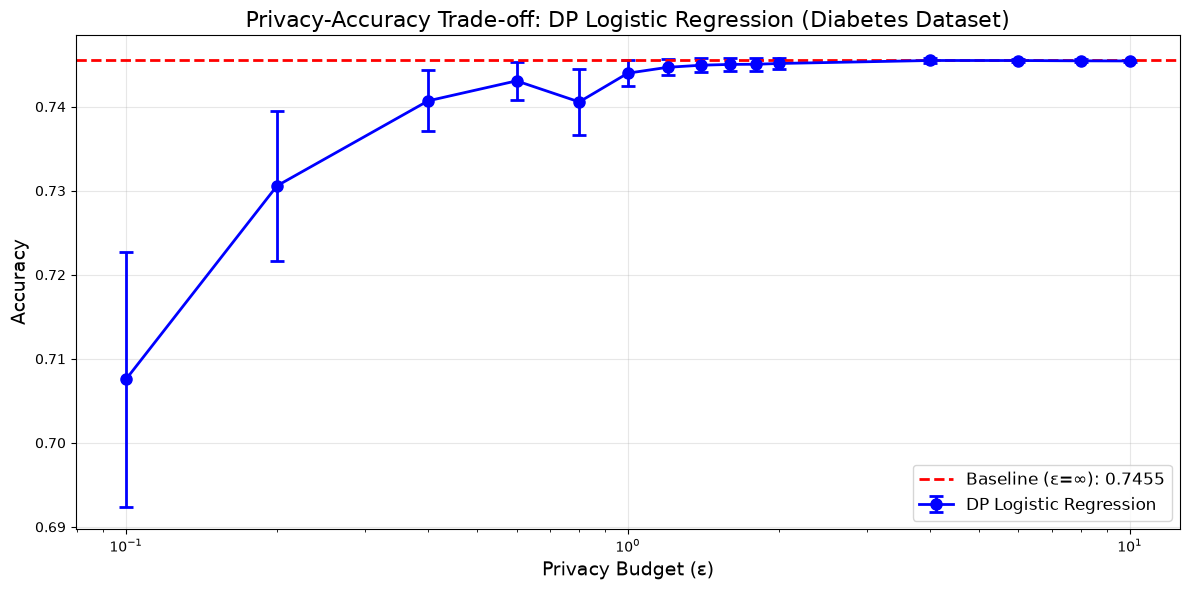

Plot saved to ./output/privacy_accuracy_tradeoff.png


In [11]:
import matplotlib.pyplot as plt

# Plot Accuracy vs Epsilon
plt.figure(figsize=(12, 6))

plt.errorbar(results_df['epsilon'], results_df['accuracy_mean'], 
             yerr=results_df['accuracy_std'], 
             marker='o', capsize=5, capthick=2, linewidth=2, markersize=8,
             label='DP Logistic Regression', color='blue')

if baseline_accuracy is not None:
    plt.axhline(y=baseline_accuracy, color='red', linestyle='--', 
                linewidth=2, label=f'Baseline (ε=∞): {baseline_accuracy:.4f}')

plt.xlabel('Privacy Budget (ε)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Privacy-Accuracy Trade-off: DP Logistic Regression (Diabetes Dataset)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig('./output/privacy_accuracy_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to ./output/privacy_accuracy_tradeoff.png")

## 9. Visualization - All Metrics vs Epsilon

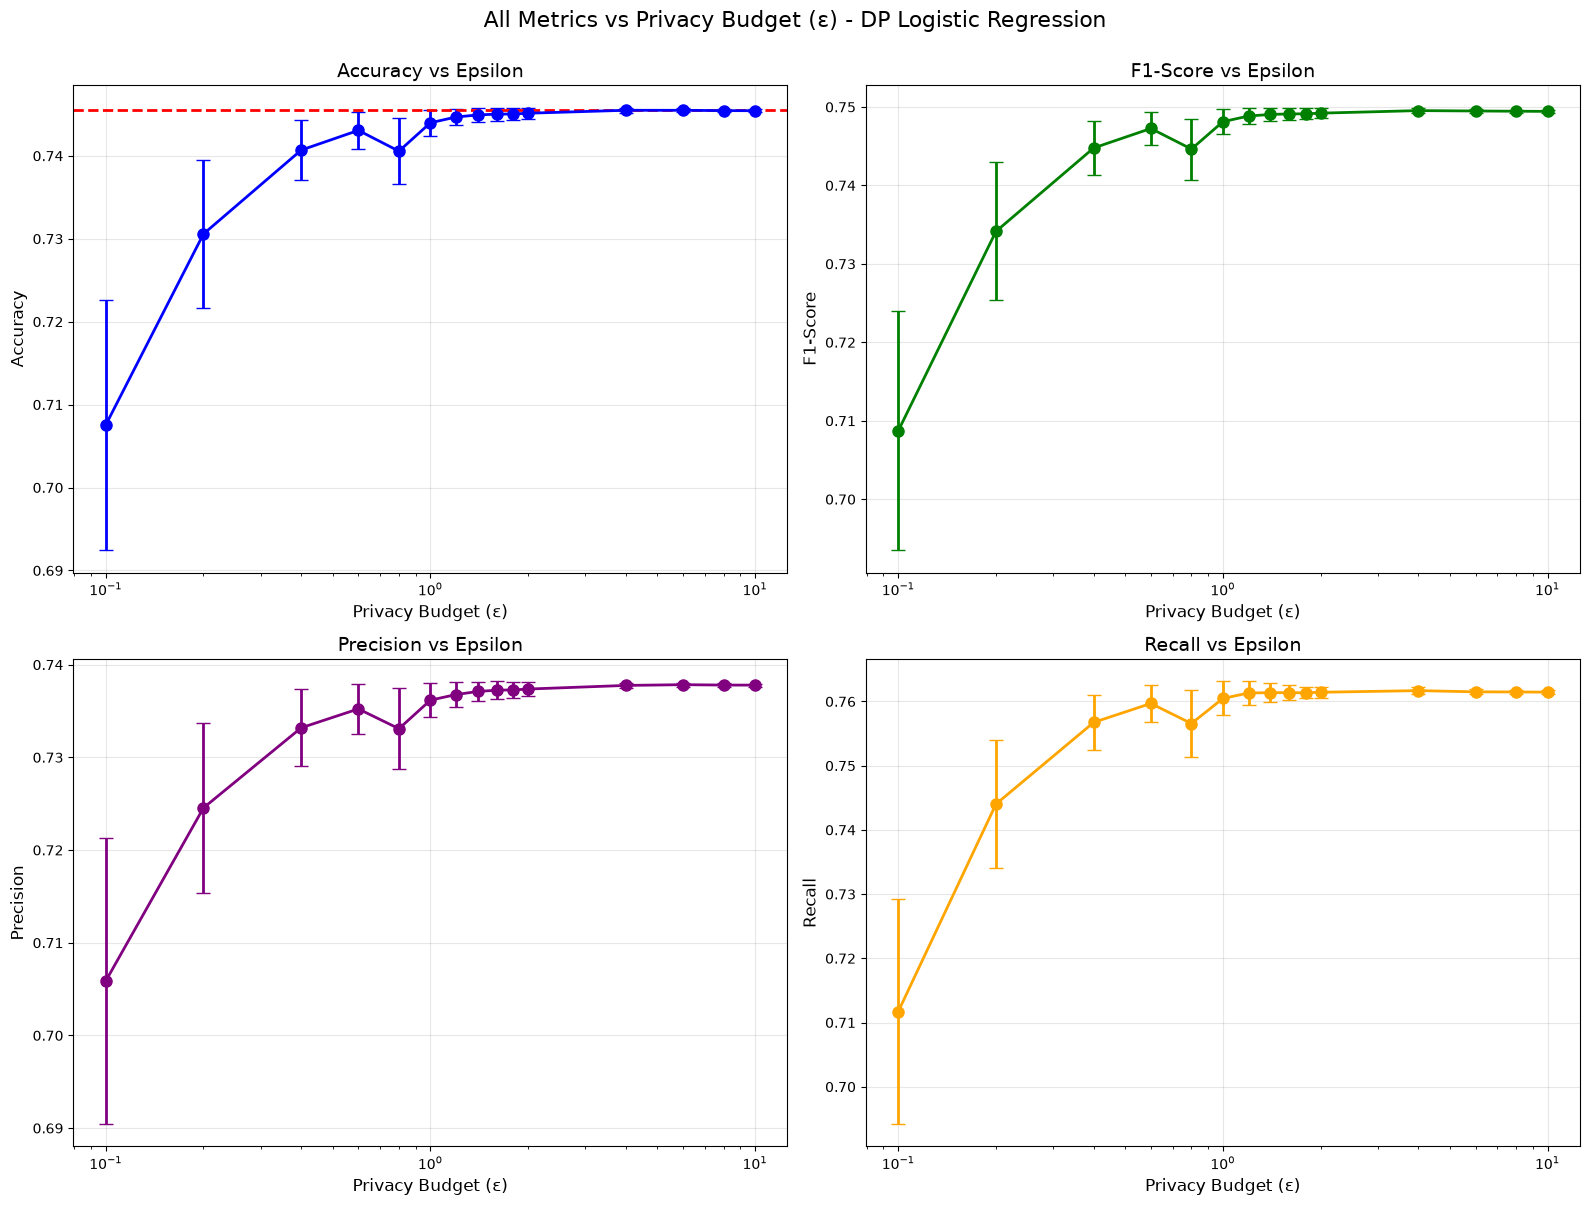

Plot saved to ./output/all_metrics_vs_epsilon.png


In [12]:
# Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy
axes[0, 0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                    yerr=results_df['accuracy_std'], marker='o', capsize=5,
                    linewidth=2, markersize=8, color='blue')
if baseline_accuracy is not None:
    axes[0, 0].axhline(y=baseline_accuracy, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Privacy Budget (ε)', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy vs Epsilon', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# F1-Score
axes[0, 1].errorbar(results_df['epsilon'], results_df['f1_score_mean'],
                    yerr=results_df['f1_score_std'], marker='o', capsize=5,
                    linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Privacy Budget (ε)', fontsize=12)
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score vs Epsilon', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

# Precision
axes[1, 0].errorbar(results_df['epsilon'], results_df['precision_mean'],
                    yerr=results_df['precision_std'], marker='o', capsize=5,
                    linewidth=2, markersize=8, color='purple')
axes[1, 0].set_xlabel('Privacy Budget (ε)', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision vs Epsilon', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# Recall
axes[1, 1].errorbar(results_df['epsilon'], results_df['recall_mean'],
                    yerr=results_df['recall_std'], marker='o', capsize=5,
                    linewidth=2, markersize=8, color='orange')
axes[1, 1].set_xlabel('Privacy Budget (ε)', fontsize=12)
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].set_title('Recall vs Epsilon', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')

plt.suptitle('All Metrics vs Privacy Budget (ε) - DP Logistic Regression', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('./output/all_metrics_vs_epsilon.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to ./output/all_metrics_vs_epsilon.png")